In [10]:
import dg_geometry as DG503
import sympy as sp
import numpy as np

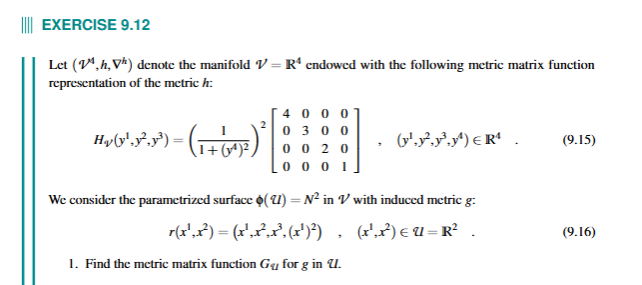

In [70]:
import sympy as sp

# Define the symbols for the coordinates y1, y2, y3, y4
y1, y2, y3, y4 = sp.symbols('y1 y2 y3 y4')


# Coordinates and Parametrization from image_0c5721.png
x1, x2, x3 = sp.symbols('x1 x2 x3', real=True)
r = sp.Matrix([x1, x2, x3, x1**2])
jac_r = r.jacobian([x1, x2])
# Define the matrix H_V(y1, y2, y3) based on equation (9.15)
# Note: The scalar factor (1 / (1 + (y4)**2))**2 is applied to the diagonal matrix
y4_sub = r[3] 
prefactor = (1 / (1 + y4_sub**2))**2

H_diagonal = sp.diag(4, 3, 2, 1)
H_V_at_r = prefactor * H_diagonal

# Displaying the results
print("Metric Tensor H_V:")
display(H_V_at_r)


print("\nJacobian of r with respect to (x1, x2):")
display(jac_r)

g_U = sp.simplify(jac_r.T * H_V_at_r * jac_r)

print("\nInduced Metric g_U on the parameter space (x1, x2):")
display(g_U)

Metric Tensor H_V:


Matrix([
[4/(x1**4 + 1)**2,                0,                0,                 0],
[               0, 3/(x1**4 + 1)**2,                0,                 0],
[               0,                0, 2/(x1**4 + 1)**2,                 0],
[               0,                0,                0, (x1**4 + 1)**(-2)]])


Jacobian of r with respect to (x1, x2):


Matrix([
[   1, 0],
[   0, 1],
[   0, 0],
[2*x1, 0]])


Induced Metric g_U on the parameter space (x1, x2):


Matrix([
[4*(x1**2 + 1)/(x1**4 + 1)**2,                0],
[                           0, 3/(x1**4 + 1)**2]])

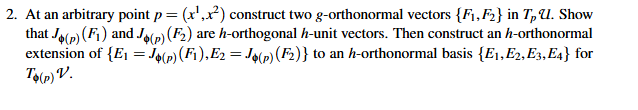

In [71]:
F1 = sp.Matrix([1, 0]) / sp.sqrt(g_U[0, 0])
F2 = sp.Matrix([0, 1]) / sp.sqrt(g_U[1, 1])

display(F1)
display(F2)

JF1 = jac_r * F1
JF2 = jac_r * F2

display(np.dot(JF1.T, JF2)[0,0])

# This follows your logic but stays purely in SymPy for better stability
h_norm_sq = (JF1.T * H_V_at_r * JF1)[0,0]
norm = sp.sqrt(h_norm_sq)

display(sp.simplify(norm))


Matrix([
[(x1**4 + 1)/(2*sqrt(x1**2 + 1))],
[                              0]])

Matrix([
[                    0],
[sqrt(3)*(x1**4 + 1)/3]])

0

1

In [73]:
import sympy as sp

# --- Extension to h-orthonormal basis {E1, E2, E3, E4} ---

# Define E1 and E2 as the push-forwards (J*F1 and J*F2)
E1 = sp.simplify(jac_r * F1)
E2 = sp.simplify(jac_r * F2)

# E3 Construction:
# Since r(x1, x2) = (x1, x2, x3, x1**2), the y3 coordinate is constant/unused.
# A vector purely in the y3 direction will be h-orthogonal to the surface's 
# x1 and x2 directions (which involve y1, y2, and y4).
import sympy as sp

# --- E3: Purely in the y3 direction ---
v3 = sp.Matrix([0, 0, 1, 0])
# Normalize using the h-metric
norm_v3 = sp.sqrt(sp.simplify((v3.T * H_V_at_r * v3)[0,0]))
E3 = v3 / norm_v3

# --- E4: Must be h-orthogonal to E1, E2, and E3 ---
# Since E1 has components in y1 and y4, v4 needs a specific ratio
# to cancel out in the h-inner product (4 * v4_y1 * E1_y1 + 1 * v4_y4 * E1_y4 = 0)
v4 = sp.Matrix([-x1/2, 0, 0, 1]) 
norm_v4 = sp.sqrt(sp.simplify((v4.T * H_V_at_r * v4)[0,0]))
E4 = v4 / norm_v4

# --- Final Verification ---
basis = [E1, E2, E3, E4]
# Build the matrix of all pair-wise h-inner products
verification = sp.Matrix([
    [sp.simplify((basis[i].T * H_V_at_r * basis[j])[0,0]) for j in range(4)] 
    for i in range(4)
])

display(sp.simplify(verification))

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

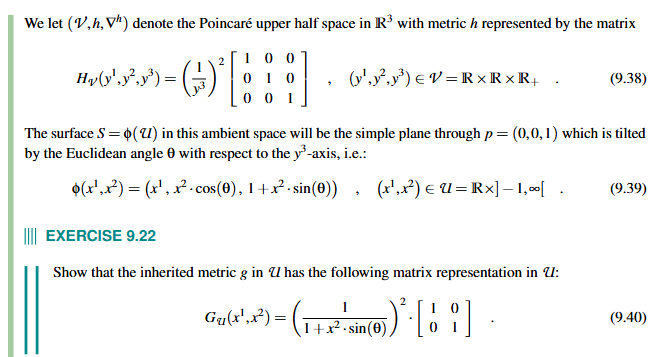

In [77]:
import sympy as sp

# Define symbols for the ambient coordinates (y1, y2, y3)
y1, y2, y3 = sp.symbols('y1 y2 y3', real=True)

# Define the metric H_V for the Poincaré upper half space (Equation 9.38)
# H_V(y1, y2, y3) = (1/y3)^2 * IdentityMatrix(3)
H_V = (1 / y3)**2 * sp.eye(3)

# Define symbols for the surface parameters (x1, x2) and the tilt angle theta
x1, x2 = sp.symbols('x1 x2', real=True)
theta = sp.symbols('theta', real=True)

# Define the parameterization phi(x1, x2) of the surface S (Equation 9.39)
# phi(x1, x2) = (x1, x2*cos(theta), 1 + x2*sin(theta))
phi = sp.Matrix([
    x1,
    x2 * sp.cos(theta),
    1 + x2 * sp.sin(theta)
])

# To find the induced metric g on the surface:
# 1. Compute the Jacobian of the parameterization
J = phi.jacobian([x1, x2])

# 2. Evaluate the ambient metric H_V on the surface (substitute y3)
y3_surface = phi[2]
H_V_surface = H_V.subs(y3, y3_surface)

# 3. Calculate g = J^T * H_V_surface * J
g = sp.simplify(J.T * H_V_surface * J)

# Display results
print("Ambient Metric H_V:")
display(H_V)
print("\nSurface Parameterization phi:")
display(phi)
print("\nInduced Metric g on the surface:")
display(g)

Ambient Metric H_V:


Matrix([
[y3**(-2),        0,        0],
[       0, y3**(-2),        0],
[       0,        0, y3**(-2)]])


Surface Parameterization phi:


Matrix([
[               x1],
[    x2*cos(theta)],
[x2*sin(theta) + 1]])


Induced Metric g on the surface:


Matrix([
[(x2*sin(theta) + 1)**(-2),                         0],
[                        0, (x2*sin(theta) + 1)**(-2)]])

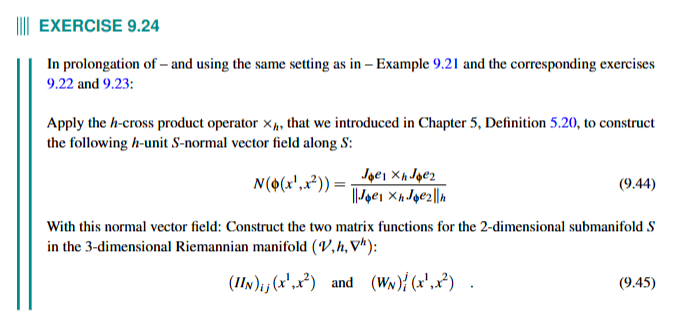

In [81]:
N_phi = J[:,0].cross(J[:,1])/sp.sqrt((J[:,0].T * H_V_surface * J[:,0])[0,0] * (J[:,1].T * H_V_surface * J[:,1])[0,0])
display(N_phi)

Matrix([
[                                                                                                                     0],
[-sin(theta)/sqrt((sin(theta)**2/(x2*sin(theta) + 1)**2 + cos(theta)**2/(x2*sin(theta) + 1)**2)/(x2*sin(theta) + 1)**2)],
[ cos(theta)/sqrt((sin(theta)**2/(x2*sin(theta) + 1)**2 + cos(theta)**2/(x2*sin(theta) + 1)**2)/(x2*sin(theta) + 1)**2)]])